# 06. 변동성 소스 × Q 방식 전체 비교

## 비교 대상 (2 × 3 = 6가지)

| | Q_FIXED (0.003) | Q_hist | Q_ff3 |
|---|---|---|---|
| **Baseline** (현재 vol_21d) | ✓ | ✓ | ✓ |
| **GARCH** (예측 vol) | ✓ | ✓ | ✓ |

## 기간
- **2011-01 ~ 2025-12** (180개월) — GARCH 예측 시작 시점에 맞춰 통일
- 공정 비교를 위해 Baseline도 동일 기간 사용

## 벤치마크
- CAPM 균형 최적화 (BL 없음)
- S&P 500 (SPY)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, re, zipfile, requests
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '06_BL_VolQ_Grid'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW = 60
TAU          = 0.1
PCT_GROUP    = 0.30
Q_FIXED      = 0.003
START_PRED   = '2011-01-01'  # GARCH 시작에 맞춰 통일

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

ret_pivot  = panel['ret_1m'].unstack('ticker')
vol_pivot  = panel['vol_21d'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')

패널: (108135, 11)
예측 기간: 2011-01-31 ~ 2025-12-31 (180개월)
Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)


In [2]:
# ── FF3 팩터 로드 ─────────────────────────────────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

def download_ff3():
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_CSV.zip')
    resp = requests.get(url, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    start = next(i for i, l in enumerate(lines) if re.match(r'^\s*\d{6}\s*,', l))
    end   = next((i for i in range(start, len(lines))
                  if not re.match(r'^\s*\d{6}\s*,', lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.rename(columns={date_col: 'date', 'Mkt-RF': 'mkt_rf',
                             'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    return df.set_index('date').astype(float) / 100.0

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

# ── GARCH 예측 vol 로드 ──────────────────────────────────────
PRED_PATH = DATA_DIR / 'vol_predicted.csv'
assert PRED_PATH.exists(), '04_VolatilityPrediction.ipynb 먼저 실행해 vol_predicted.csv 생성하세요'
vol_pred_df    = pd.read_csv(PRED_PATH, parse_dates=['date'])
vol_pred_pivot = vol_pred_df.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')
print(f'GARCH 예측 로드: {vol_pred_pivot.shape}')

FF3 로드: (1196, 4)
GARCH 예측 로드: (180, 610)


In [3]:
# ── BL 구성 함수 ──────────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_Q_hist(P, ret_matrix):
    p_vec = P.reindex(ret_matrix.columns).fillna(0).values
    return float((ret_matrix.values @ p_vec).mean())


def compute_Q_ff3(P, ret_matrix, ff3_train, rf_train):
    view_tickers = [t for t in P[P != 0].index if t in ret_matrix.columns]
    if not view_tickers:
        return 0.0
    ff3_aligned = ff3_train.reindex(ret_matrix.index).dropna()
    rf_aligned  = rf_train.reindex(ff3_aligned.index).fillna(0)
    n = len(ff3_aligned)
    if n < 24:
        return 0.0
    X      = np.column_stack([np.ones(n), ff3_aligned[['mkt_rf', 'smb', 'hml']].values])
    X_next = np.array([1.0] + ff3_aligned[['mkt_rf', 'smb', 'hml']].tail(12).mean().tolist())
    rf_next = float(rf_train.iloc[-1]) if len(rf_train) > 0 else 0.0
    Y    = (ret_matrix[view_tickers].reindex(ff3_aligned.index).fillna(0).values
            - rf_aligned.values.reshape(-1, 1))
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    r_hat_view = X_next @ coef + rf_next
    r_hat = pd.Series(0.0, index=ret_matrix.columns)
    for j, t in enumerate(view_tickers):
        r_hat[t] = r_hat_view[j]
    return float(P.reindex(ret_matrix.columns).fillna(0) @ r_hat)


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)


print('BL 함수 정의 완료')

BL 함수 정의 완료


In [4]:
# ── Walk-forward: 2 vol-source × 3 Q-method 동시 실행 ─────────
#
# 매 pred_date마다:
#   1. 공통 인프라 계산 (ret_slice, train_dates)
#   2. vol_source별 (Baseline / GARCH):
#      a. vol_use 결정 → P 구성
#      b. Sigma 계산 (vol_source와 무관하게 ret_slice 기반)
#      c. pi, lam 계산
#      d. Q 3종 계산 → BL → 최적화

COMBOS = [
    ('Baseline', 'Q_FIXED'),
    ('Baseline', 'Q_hist'),
    ('Baseline', 'Q_ff3'),
    ('GARCH',    'Q_FIXED'),
    ('GARCH',    'Q_hist'),
    ('GARCH',    'Q_ff3'),
]

results = {k: [] for k in [f'{v}+{q}' for v, q in COMBOS]}
results['CAPM'] = []
results['SPY']  = []

print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'비교 조합: {len(COMBOS)}개 + CAPM + SPY')

for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')

    try:
        # ── 공통: 기본 데이터 준비 ───────────────────────────
        month_base = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_base) < 30:
            continue

        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        rf_s        = rf_series.reindex(train_dates)
        spy_s       = spy_series.reindex(train_dates)
        spy_excess  = (spy_s - rf_s).mean()
        sigma2_mkt  = spy_s.var()

        next_date = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        r_spy     = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # ── vol_source별 반복 ────────────────────────────────
        capm_added = False

        for vol_name in ['Baseline', 'GARCH']:
            month_df = month_base.copy()

            if vol_name == 'GARCH' and pred_date in vol_pred_pivot.index:
                pred_vol = vol_pred_pivot.loc[pred_date].reindex(month_df.index)
                month_df['vol_use'] = pred_vol
                month_df = month_df.dropna(subset=['vol_use'])
            else:
                month_df['vol_use'] = month_df['vol_21d']

            if len(month_df) < 20:
                continue

            universe  = month_df.index.tolist()
            thresh    = int(len(train_dates) * 0.7)
            ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                                  .dropna(axis=1, thresh=thresh)
                                  .fillna(0))
            valid_tix = ret_slice.columns.tolist()
            if len(valid_tix) < 20:
                continue

            month_df = month_df.reindex(valid_tix)
            Sigma    = compute_sigma(ret_slice)
            mcap     = np.exp(month_df['log_mcap'])
            w_mkt    = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
            pi, lam  = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)

            P     = build_P(month_df['vol_use'], mcap, pct=PCT_GROUP)
            P     = P.reindex(valid_tix).fillna(0)
            omega = compute_omega(P, Sigma, TAU)

            # Q 3종 계산
            q_fixed = Q_FIXED
            q_hist  = compute_Q_hist(P, ret_slice)
            q_ff3   = compute_Q_ff3(P, ret_slice, ff3.reindex(train_dates), rf_s)

            actual_ret = month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0)

            for q_name, q_val in [('Q_FIXED', q_fixed), ('Q_hist', q_hist), ('Q_ff3', q_ff3)]:
                key   = f'{vol_name}+{q_name}'
                mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
                w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
                results[key].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})

            # CAPM은 vol_source와 무관 → Baseline 루프에서 한 번만 추가
            if not capm_added and vol_name == 'Baseline':
                w_capm = optimize_portfolio(pi, Sigma, lam)
                results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
                results['SPY'].append({'date': pred_date, 'ret': r_spy})
                capm_added = True

    except Exception as e:
        if i < 5:
            print(f'  [에러] {pred_date.date()}: {e}')

# DataFrame 변환
ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
              for k, v in results.items() if v}

print(f'\n완료')
for k, s in ret_series.items():
    print(f'  {k}: {len(s)}개월')

Walk-forward: 2011-01-31 ~ 2025-12-31 (180개월)
비교 조합: 6개 + CAPM + SPY
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료
  Baseline+Q_FIXED: 180개월
  Baseline+Q_hist: 180개월
  Baseline+Q_ff3: 180개월
  GARCH+Q_FIXED: 180개월
  GARCH+Q_hist: 180개월
  GARCH+Q_ff3: 180개월
  CAPM: 180개월
  SPY: 180개월


In [5]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN        = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf     = rf_monthly.reindex(ret.index).fillna(0)
    excess = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    return {'label': label, 'ann_ret': ann_ret, 'ann_vol': ann_vol,
            'sharpe': sharpe, 'cum_ret': cum_ret, 'mdd': mdd}

# 표시 순서
ORDER = [
    'Baseline+Q_FIXED', 'Baseline+Q_hist', 'Baseline+Q_ff3',
    'GARCH+Q_FIXED',    'GARCH+Q_hist',    'GARCH+Q_ff3',
    'CAPM', 'SPY',
]

stats_list = [performance(ret_series[k], k) for k in ORDER if k in ret_series]
stats_df   = pd.DataFrame(stats_list).set_index('label')

disp = stats_df.copy()
disp['ann_ret'] = disp['ann_ret'].map('{:.2%}'.format)
disp['ann_vol'] = disp['ann_vol'].map('{:.2%}'.format)
disp['sharpe']  = disp['sharpe'].map('{:.3f}'.format)
disp['cum_ret'] = disp['cum_ret'].map('{:.2%}'.format)
disp['mdd']     = disp['mdd'].map('{:.2%}'.format)
disp.columns    = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']

print('=' * 70)
print('전체 포트폴리오 성과 비교 (2011-01 ~ 2025-12)')
print('=' * 70)
print(disp.to_string())

전체 포트폴리오 성과 비교 (2011-01 ~ 2025-12)
                  연환산수익률  연환산변동성 Sharpe    누적수익률      MDD
label                                                    
Baseline+Q_FIXED  13.77%  11.44%  1.074  608.29%  -13.70%
Baseline+Q_hist   14.19%  14.24%  0.896  613.83%  -21.57%
Baseline+Q_ff3    11.26%  16.79%  0.586  332.93%  -51.48%
GARCH+Q_FIXED     13.50%  11.81%  1.019  575.70%  -16.73%
GARCH+Q_hist      12.81%  13.24%  0.859  493.99%  -19.50%
GARCH+Q_ff3       11.42%  17.94%  0.557  331.08%  -54.37%
CAPM              14.21%  14.49%  0.882  612.78%  -22.17%
SPY               14.03%  14.06%  0.898     nan%  -23.93%


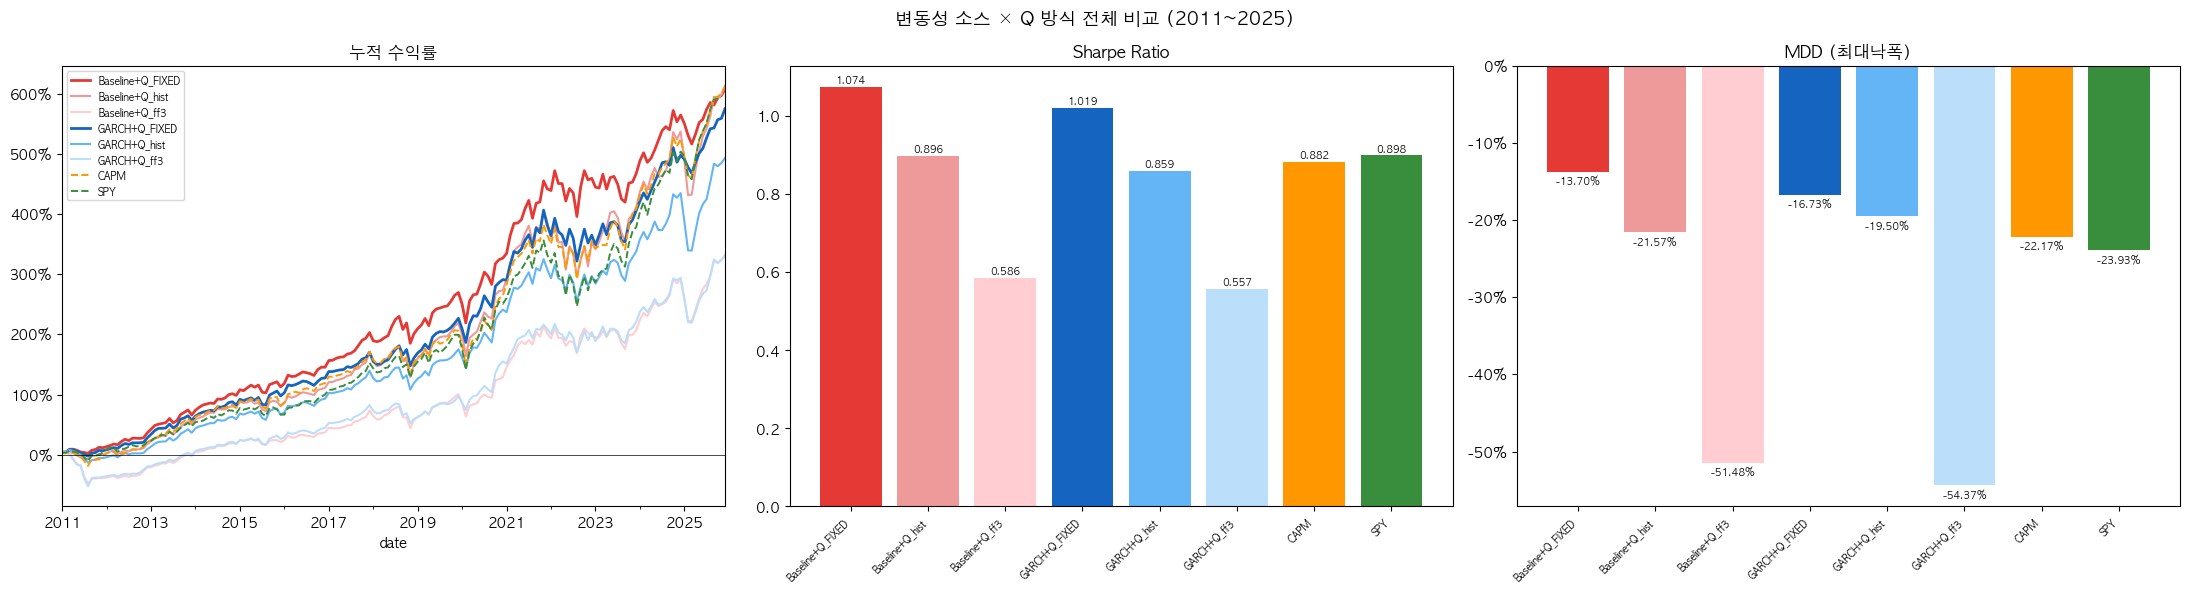

저장 완료


In [6]:
# ── 시각화 ───────────────────────────────────────────────────
STYLE = {
    'Baseline+Q_FIXED': ('#E53935', '-',  2.0),
    'Baseline+Q_hist':  ('#EF9A9A', '-',  1.5),
    'Baseline+Q_ff3':   ('#FFCDD2', '-',  1.5),
    'GARCH+Q_FIXED':    ('#1565C0', '-',  2.0),
    'GARCH+Q_hist':     ('#64B5F6', '-',  1.5),
    'GARCH+Q_ff3':      ('#BBDEFB', '-',  1.5),
    'CAPM':             ('#FF9800', '--', 1.4),
    'SPY':              ('#388E3C', '--', 1.4),
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('변동성 소스 × Q 방식 전체 비교 (2011~2025)', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for k in ORDER:
    if k not in ret_series:
        continue
    color, ls, lw = STYLE[k]
    cum = (1 + ret_series[k]).cumprod() - 1
    cum.plot(ax=ax, label=k, color=color, linestyle=ls, linewidth=lw)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=7)
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio
ax = axes[1]
keys    = [s['label'] for s in stats_list]
sharpes = [s['sharpe'] for s in stats_list]
colors  = [STYLE[k][0] for k in keys]
bars = ax.bar(range(len(keys)), sharpes, color=colors)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=7)
ax.set_title('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# ③ MDD
ax = axes[2]
mdds = [s['mdd'] for s in stats_list]
bars = ax.bar(range(len(keys)), mdds, color=colors)
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=7)
ax.set_title('MDD (최대낙폭)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, mdds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.005,
            f'{val:.2%}', ha='center', va='top', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'vol_q_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame(ret_series)
result_df.to_csv(DATA_DIR / 'vol_q_grid_returns.csv')
stats_df.to_csv(OUT_DIR / 'vol_q_grid_stats.csv')
print('저장 완료')